In [19]:
%pip install -q fsspec tensorflow_decision_forests scikit-learn ydf miceforest matplotlib

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import ydf
import miceforest as mf

In [3]:
df = pd.read_csv('./Titanic-Dataset.csv')

In [4]:
df["FamSize"] = df["SibSp"] + df["Parch"] + 1
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Fare'] = df['Fare'].fillna(df['Fare'].median())
df['Embarked'] = df['Embarked'].fillna('S')

In [5]:
df['Deck'] = df['Cabin'].apply(lambda x: str(x)[0] if pd.notnull(x) else 'U')
df['Has_Cabin'] = df['Cabin'].notnull().astype(int)
df = df.drop('Cabin', axis=1)

# Optional: Group rare decks
# deck_counts = df['Deck'].value_counts()
# rare_decks = deck_counts[deck_counts < 10].index
# df['Deck'] = df['Deck'].replace(rare_decks, 'R')

In [6]:
feats = ['Survived', 'Pclass', 'Sex', 'Age', 'Fare', 'Embarked', 'FamSize', 'Deck', 'Has_Cabin']
model = ydf.GradientBoostedTreesLearner(label='Survived').train(df[feats])
model.describe()

Train model on 891 examples
Model trained in 0:00:00.171006


In [12]:
p = model.predict(df[feats])

In [31]:
from sklearn.ensemble import IsolationForest

df = df.dropna()

clf = IsolationForest(random_state=0).fit(df[['Fare', 'Age']])

clf.predict(df[['Fare', 'Age']])

array([ 1,  1,  1,  1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1, -1, -1,
        1,  1,  1,  1,  1,  1,  1, -1,  1,  1, -1,  1,  1,  1, -1,  1, -1,
        1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1, -1,
        1, -1,  1, -1,  1,  1,  1, -1, -1,  1,  1, -1, -1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1,  1,  1, -1,  1, -1,  1, -1,  1,  1,  1,  1,  1,
       -1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1, -1,  1, -1,
       -1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1,
        1,  1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1, -1,
        1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1, -1, -1,  1,  1,  1,  1,
       -1, -1, -1,  1, -1,  1,  1,  1,  1, -1,  1,  1, -1, -1, -1,  1,  1,
        1,  1,  1,  1,  1,  1, -1,  1, -1,  1,  1,  1,  1,  1,  1,  1,  1,
        1, -1,  1,  1,  1,  1,  1,  1,  1,  1,  1, -1,  1,  1,  1,  1,  1,
        1,  1,  1, -1,  1

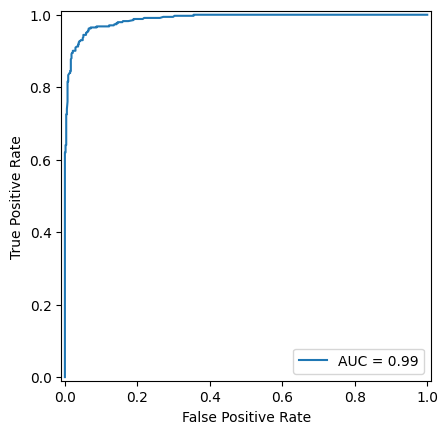

In [23]:
from sklearn.metrics import roc_auc_score, roc_curve, auc, RocCurveDisplay, PrecisionRecallDisplay, precision_recall_curve
import matplotlib.pyplot as plt

fpr, tpr, _ = roc_curve(df['Survived'], p)

roc_auc = auc(fpr, tpr)

display = RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()

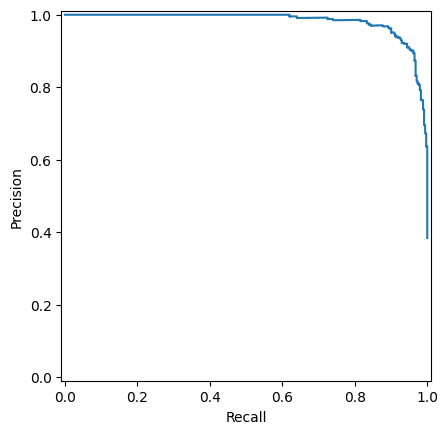

In [25]:
precision, recall, _ = precision_recall_curve(df['Survived'], p)

roc_auc = auc(recall, precision)

display = PrecisionRecallDisplay(recall=recall, precision=precision)
display.plot()

In [ ]:
# TODO: outs

# TODO: cross-val, rand